In [200]:
# Dataset Exploration & Preprocessing
# Internship Task - SWYNEX Technologies

print("Dataset Exploration & Preprocessing")

Dataset Exploration & Preprocessing


# Dataset Exploration & Preprocessing

## SWYNEX Technologies – Internship Task

### Objective

The objective of this task is to explore, clean and preprocess a dataset for machine learning.

In this task, the dataset will be analyzed to understand its structure, identify missing values, handle categorical variables, prepare features and target variables, and perform necessary preprocessing before machine learning model training.

### Tasks Performed

- Dataset exploration
- Exploratory data analysis
- Missing value identification and handling
- Categorical variable encoding
- Feature and target preparation
- Train-test splitting
- Feature scaling
- Final data validation

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

## 1. Dataset Selection

For this task, the Titanic dataset is selected for exploration and preprocessing.

The dataset contains information about passengers, including demographic details, ticket class, fare, age and survival status.

The dataset is suitable for demonstrating preprocessing because it contains:

- Numerical variables
- Categorical variables
- Missing values
- A target variable
- Features that require preprocessing

In [202]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Dataset Overview

Before preprocessing the dataset, its structure and characteristics are examined.

The following information will be checked:

- Number of rows and columns
- Column names
- Data types
- Statistical summary
- First few records

In [203]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 15


In [204]:
# Display column names

print("Column names:")
print(df.columns.tolist())

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [206]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [207]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [208]:
missing_values = df.isnull().sum()

print(missing_values)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [209]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand patterns, distributions and relationships within the dataset.

Different visualizations are used to understand the data before preprocessing.

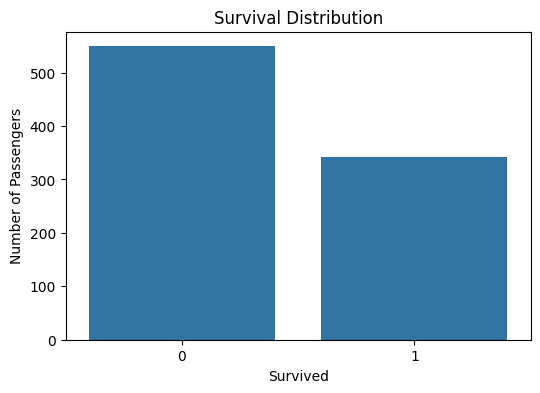

In [210]:
# Distribution of survival status

plt.figure(figsize=(6, 4))

sns.countplot(x='survived', data=df)

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

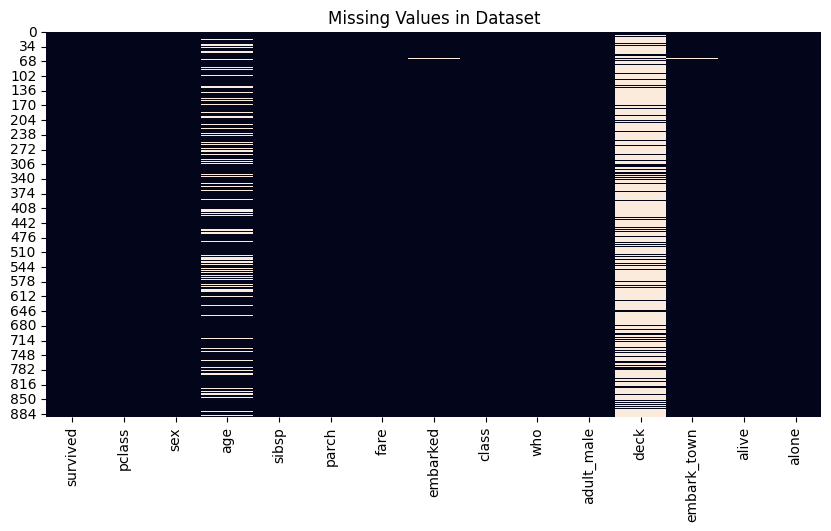

In [211]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Dataset")
plt.show()

### Observation

The count plot shows the distribution of passengers according to their survival status.

This helps us understand the distribution of the target variable.

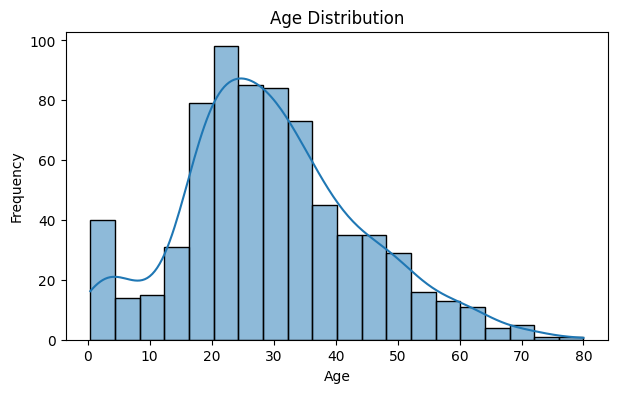

In [212]:
# Distribution of passenger age

plt.figure(figsize=(7, 4))

sns.histplot(df['age'], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

The age distribution shows how passenger ages are distributed across the dataset.

The presence of missing age values will be handled during the data cleaning stage.

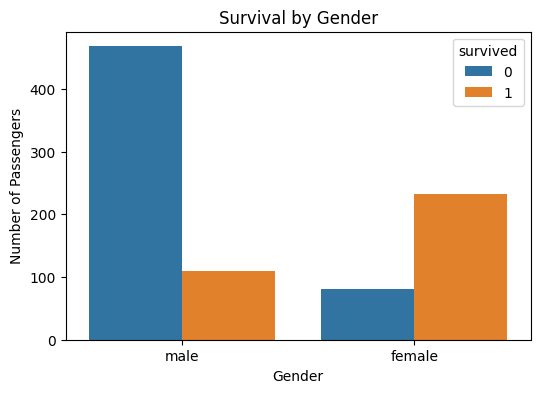

In [213]:
# Relationship between gender and survival

plt.figure(figsize=(6, 4))

sns.countplot(x='sex', hue='survived', data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

The visualization compares survival outcomes across different genders and helps identify patterns in the target variable.

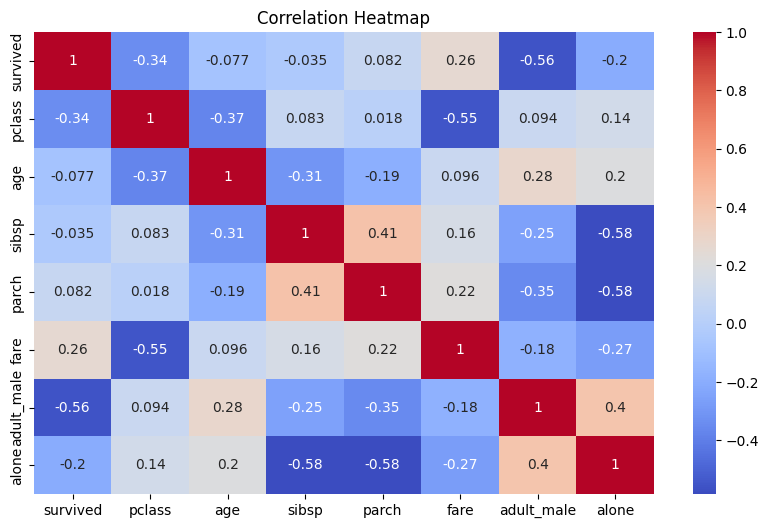

In [214]:
# Correlation between numerical variables

plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## 4. Missing Value Analysis

Missing values can negatively affect machine learning models.

Therefore, missing values are identified before further preprocessing.

In [215]:
# Count missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [216]:
# Calculate missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


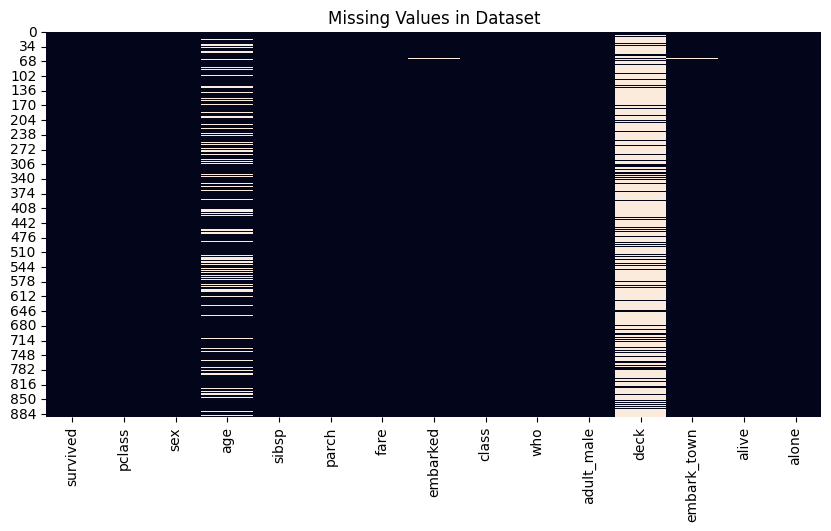

In [217]:
# Visualize missing values

plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Dataset")

plt.show()

## 5. Data Cleaning

Before applying machine learning preprocessing, redundant columns are removed.

Missing values are not filled manually at this stage. Instead, they will be handled inside a preprocessing pipeline after the train-test split.

This approach helps prevent data leakage because imputation statistics are learned only from the training data.

In [218]:
# Remove the deck column because it contains a large proportion of missing values

df = df.drop(columns=['deck'])

print("Deck column removed successfully.")
print("Remaining missing values:")
print(df.isnull().sum())

Deck column removed successfully.
Remaining missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64


In [219]:
# Verify missing values after cleaning

print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64


## 6. Removing Redundant Features

Some columns contain redundant or derived information that is not required for the selected machine learning task.

The following columns are removed:

- `alive`
- `embark_town`
- `who`
- `adult_male`

Removing these features reduces redundancy and keeps the feature set focused.

In [220]:
# Remove redundant and derived columns

redundant_columns = [
    'alive',
    'embark_town',
    'who',
    'adult_male'
]

df = df.drop(columns=redundant_columns)

print("Redundant columns removed successfully.")
print("Remaining columns:")
print(df.columns.tolist())

Redundant columns removed successfully.
Remaining columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'alone']


## 7. Train-Test Split Before Preprocessing

The dataset is first divided into training and testing sets before applying preprocessing.

This is an important machine learning practice because preprocessing parameters should be learned only from the training data.

The test data must remain unseen during the fitting process to prevent data leakage.

In [221]:
# Separate features and target

X = df.drop(columns=['survived'])
y = df['survived']

# Split the dataset before preprocessing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (712, 9)
Testing data shape: (179, 9)


## 8. Identifying Numerical and Categorical Features

The input features are divided into numerical and categorical groups.

Numerical features will undergo missing-value imputation and standardization.

Categorical features will undergo missing-value imputation followed by one-hot encoding.

In [222]:
# Define numerical and categorical features

numerical_features = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

categorical_features = [
    'sex',
    'embarked',
    'class',
    'alone'
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked', 'class', 'alone']


## 9. Building the Preprocessing Pipeline

A ColumnTransformer-based preprocessing pipeline is used to apply different transformations to numerical and categorical features.

### Numerical Features
- Missing values are replaced using the median.
- Features are standardized using StandardScaler.

### Categorical Features
- Missing values are replaced using the most frequent value.
- Categorical variables are converted into numerical features using OneHotEncoder.

The preprocessing pipeline is fitted only on the training data to prevent data leakage.

In [223]:
# Numerical preprocessing pipeline

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False
    ))
])

# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, numerical_features),
        ('categorical', categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 10. Applying the Preprocessing Pipeline

The preprocessing pipeline is fitted using only the training data.

The same fitted transformations are then applied to the test data.

This ensures that information from the test set does not influence the preprocessing process.

In [224]:
# Fit preprocessing on training data
# and transform both training and testing data

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (712, 11)
Testing data after preprocessing: (179, 11)


## 11. Processed Feature Information

After encoding, the original categorical variables are converted into numerical feature columns.

The generated feature names are extracted to verify the final machine learning feature set.

In [225]:
# Get names of transformed features

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed feature names:")
print(feature_names)

Number of processed features: 11

Processed feature names:
['numerical__pclass' 'numerical__age' 'numerical__sibsp'
 'numerical__parch' 'numerical__fare' 'categorical__sex_male'
 'categorical__embarked_Q' 'categorical__embarked_S'
 'categorical__class_Second' 'categorical__class_Third'
 'categorical__alone_True']


In [226]:
# Convert processed arrays into DataFrames

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Processed training data:")
display(X_train_processed_df.head())

Processed training data:


,numerical__pclass,numerical__age,numerical__sibsp,numerical__parch,numerical__fare,categorical__sex_male,categorical__embarked_Q,categorical__embarked_S,categorical__class_Second,categorical__class_Third,categorical__alone_True
692,0.829568,-0.081135,-0.465084,-0.466183,0.513812,1.0,0.0,1.0,0.0,1.0,1.0
481,-0.370945,-0.081135,-0.465084,-0.466183,-0.662563,1.0,0.0,1.0,1.0,0.0,1.0
527,-1.571457,-0.081135,-0.465084,-0.466183,3.955399,1.0,0.0,1.0,0.0,0.0,1.0
855,0.829568,-0.887827,-0.465084,0.727782,-0.467874,0.0,0.0,1.0,0.0,1.0,0.0
801,-0.370945,0.110934,0.478335,0.727782,-0.115977,0.0,0.0,1.0,1.0,0.0,0.0


## 12. Final Data Validation

The processed datasets are checked to ensure that:

- Missing values have been handled.
- All features are numerical.
- Training and testing datasets contain the same feature columns.
- The preprocessing pipeline has been applied consistently.

In [227]:
# Final validation

print("Missing values in training data:",
      X_train_processed_df.isnull().sum().sum())

print("Missing values in testing data:",
      X_test_processed_df.isnull().sum().sum())

print("\nTraining data shape:",
      X_train_processed_df.shape)

print("Testing data shape:",
      X_test_processed_df.shape)

print("\nAll processed features are numerical:",
      X_train_processed_df.dtypes.apply(
          lambda x: np.issubdtype(x, np.number)
      ).all())

Missing values in training data: 0
Missing values in testing data: 0

Training data shape: (712, 11)
Testing data shape: (179, 11)

All processed features are numerical: True


## 13. Saving the Preprocessed Dataset

The processed training and testing data are saved for future machine learning model development.

The preprocessing pipeline can also be reused to transform new data consistently.

In [228]:
# Combine processed training and testing data

X_processed = pd.concat([
    X_train_processed_df,
    X_test_processed_df
]).sort_index()

# Add target variable

processed_dataset = X_processed.copy()
processed_dataset['survived'] = y

# Save the final processed dataset

processed_dataset.to_csv(
    "titanic_preprocessed.csv",
    index=False
)

print("Preprocessed dataset saved successfully!")
print("Final dataset shape:", processed_dataset.shape)

Preprocessed dataset saved successfully!
Final dataset shape: (891, 12)


# Conclusion

The Titanic dataset was successfully explored and prepared for machine learning.

The following steps were completed:

- Dataset structure and statistical characteristics were explored.
- Exploratory data analysis was performed using multiple visualizations.
- Missing values were identified and analyzed.
- Redundant features were removed.
- The dataset was split into training and testing sets before preprocessing.
- Numerical features were imputed and standardized.
- Categorical features were imputed and one-hot encoded.
- A ColumnTransformer-based preprocessing pipeline was implemented.
- Preprocessing was fitted only on the training data to prevent data leakage.
- The processed dataset was validated and exported.

The resulting dataset is now ready for machine learning model development.